In [ ]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [ ]:
# Core libs
%pip install matplotlib==3.9.0 \
datasets==2.20.0 pyarrow==15.0.2 \
lime==0.2.0.1 shap==0.45.1 scipy tqdm pandas

In [1]:
import random

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset, Dataset

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm

from lime.lime_text import LimeTextExplainer
import shap

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [3]:
dataset = load_dataset("imdb")

In [4]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [5]:
def build_prompt(review):

    prompt = f"""Review: {review}

Sentiment:"""

    return prompt


def build_full_text(review, label):

    sentiment = (
        "positive"
        if label == 1
        else "negative"
    )

    full_text = f"""Review: {review}

Sentiment: {sentiment}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):

    text_list = []
    input_ids_list = []
    attention_masks_list = []
    labels_list = []
    true_labels_list = []

    for example in dataset:

        review = example["text"]
        label = example["label"]

        prompt = build_prompt(review)
        full_text = build_full_text(review, label)

        # =========================
        # TOKENIZACIÓN
        # =========================

        full = tokenizer(
            full_text,
            add_special_tokens=False
        )

        input_ids = full["input_ids"]

        # attention mask inicial
        attention_mask = [1] * len(input_ids)

        # =========================
        # LABELS (SIN prompt_len)
        # =========================

        labels = []

        # reconstruimos prompt tokenizado directamente dentro del full_text
        prompt_text = build_prompt(review)

        prompt_ids = tokenizer(
            prompt_text,
            add_special_tokens=False
        )["input_ids"]

        # ⚠️ no asumimos alineación por slicing, buscamos corte seguro por longitud
        prompt_len = len(prompt_ids)

        for i, tok in enumerate(input_ids):

            if i < prompt_len:
                labels.append(-100)
            else:
                labels.append(tok)

        # =========================
        # PADDING / TRUNCATION UNIFORME
        # =========================

        if len(input_ids) > MAX_LENGTH:

            input_ids = input_ids[:MAX_LENGTH]
            attention_mask = attention_mask[:MAX_LENGTH]
            labels = labels[:MAX_LENGTH]

        else:

            pad_len = MAX_LENGTH - len(input_ids)

            input_ids += [tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
            labels += [-100] * pad_len

        # =========================
        # TRUE LABEL EXPLÍCITO
        # =========================

        true_label = "positive" if label == 1 else "negative"

        # =========================
        # STORE
        # =========================

        text_list.append(review)
        input_ids_list.append(input_ids)
        attention_masks_list.append(attention_mask)
        labels_list.append(labels)
        true_labels_list.append(true_label)

    return Dataset.from_dict({
        "texts": text_list,
        "input_ids": input_ids_list,
        "attention_mask": attention_masks_list,
        "labels": labels_list,
        "true_label": true_labels_list
    })

In [6]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [7]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [8]:
# Reviews exceeding model context are removed from the dataset.
BATCH_SIZE = 1

filtered_test = dataset["test"].filter(
    fits_model
)

test_dataset = preprocess_dataset(filtered_test, tokenizer)

test_dataset.set_format(
    type="torch",
    columns=[
        "texts",
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [9]:
test_dataset[0]

{'texts': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it\'s rubbish as

In [10]:
CHECKPOINT_DIR = "../checkpoints/imdb"

config_11 = AutoConfig.from_pretrained(MODEL_NAME, local_files_only=True)
config_11.num_hidden_layers = 11

def load_model(num_layers, ckpt_name):
    if num_layers == 22:
        m = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, local_files_only=True, attn_implementation="eager"
        )
    else:
        m = AutoModelForCausalLM.from_config(config_11)
    m.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/{ckpt_name}", map_location="cpu"))
    m.eval()
    return m

MODELS = {
    "teacher":       load_model(22, "best_teacher_model.pt"),
    "baseline":      load_model(11, "best_baseline_model.pt"),
    "bad_student":   load_model(11, "best_bad_student_model.pt"),
    "student":       load_model(11, "best_student_model.pt"),
    "student_local": load_model(11, "best_student_local_model.pt"),
}

MODEL_LABELS = {
    "teacher":       "P (teacher)",
    "baseline":      "B (baseline, no KD)",
    "bad_student":   "S_bad",
    "student":       "S1",
    "student_local": "S2",
}

print("Loaded:", list(MODELS.keys()))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3554.45it/s]


Loaded: ['teacher', 'baseline', 'bad_student', 'student', 'student_local']


In [11]:
positive_id = tokenizer.encode(" positive", add_special_tokens=False)[0]
negative_id = tokenizer.encode(" negative", add_special_tokens=False)[0]

def make_prompt(text):
    return f"Review: {text}\n\nSentiment:"

def classify_fn(texts, model, batch_size=8):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    texts = [str(t) for t in texts]
    prompts = [make_prompt(t) for t in texts]
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch_size):
            batch = prompts[i:i + batch_size]
            enc = tokenizer(
                batch, return_tensors="pt", truncation=True, padding=True
            ).to(device)
            logits = model(**enc).logits
            last_idx = enc["attention_mask"].sum(dim=1) - 1
            logits = logits[torch.arange(len(batch), device=device), last_idx]
            binary = torch.stack([logits[:, negative_id], logits[:, positive_id]], dim=1)
            probs = F.softmax(binary, dim=-1)
            all_probs.append(probs.float().cpu().numpy())
    return np.concatenate(all_probs, axis=0)

# ── Evaluation subset: N=100 (50 neg + 50 pos, fixed seed) ──────────────
random.seed(42)
pos_indices = [i for i in range(len(test_dataset)) if test_dataset[i]["true_label"] == "positive"]
neg_indices = [i for i in range(len(test_dataset)) if test_dataset[i]["true_label"] == "negative"]

eval_pos = random.sample(pos_indices, 50)
eval_neg = random.sample(neg_indices, 50)
eval_indices = eval_neg + eval_pos
eval_texts  = [test_dataset[i]["texts"] for i in eval_indices]
eval_labels = [test_dataset[i]["true_label"] for i in eval_indices]

QUAL_NEG = test_dataset[neg_indices[0]]["texts"]
QUAL_POS = test_dataset[pos_indices[0]]["texts"]

print(f"Eval subset: {len(eval_texts)} examples  "
      f"({eval_labels.count('negative')} neg / {eval_labels.count('positive')} pos)")
print(f"Qualitative neg idx={neg_indices[0]}  pos idx={pos_indices[0]}")

Eval subset: 100 examples  (50 neg / 50 pos)
Qualitative neg idx=0  pos idx=12500


# Helper Functions

In [12]:
# ── tokens → word-level aggregation ────────────────────────────────────
def tokens_to_words(tokens, scores):
    words, word_scores = [], []
    current_word, current_scores = "", []
    for token, score in zip(tokens, scores):
        if token.startswith("▁") or token.startswith("Ġ"):
            if current_word:
                words.append(current_word)
                word_scores.append(float(np.mean(current_scores)))
            current_word = token.lstrip("▁").lstrip("Ġ")
            current_scores = [score]
        else:
            current_word += token
            current_scores.append(score)
    if current_word:
        words.append(current_word)
        word_scores.append(float(np.mean(current_scores)))
    return words, np.array(word_scores)


# ── Integrated Gradients (zero baseline, signed output) ─────────────────
def integrated_gradients(model, input_ids, target_token_idx, steps=50):
    emb = model.get_input_embeddings()(input_ids)
    baseline = torch.zeros_like(emb)          # zero = "absence of information"
    grads = []
    for alpha in torch.linspace(0, 1, steps):
        interp = (baseline + alpha * (emb - baseline)).detach().requires_grad_(True)
        score = model(inputs_embeds=interp).logits[0, -1, target_token_idx]
        score.backward()
        grads.append(interp.grad.clone())
    avg_grads = torch.stack(grads).mean(dim=0)
    return ((emb - baseline) * avg_grads).sum(dim=-1).squeeze(0)  # signed, [seq_len]


def get_ig_scores(model, text, target_id):
    """Returns {word: signed_ig_score} for the review text portion."""
    prompt = make_prompt(text)
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    ig = integrated_gradients(model, enc["input_ids"], target_id)

    prefix_len = len(tokenizer("Review: ", add_special_tokens=False)["input_ids"])
    text_len   = len(tokenizer(text,       add_special_tokens=False)["input_ids"])
    start = prefix_len + 1   # +1 for <s>
    end   = start + text_len

    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    words, wscores = tokens_to_words(
        toks[start:end],
        ig.float().detach().cpu().numpy()[start:end]
    )
    return dict(zip(words, wscores.tolist()))


# ── LIME attribution getter ─────────────────────────────────────────────
def get_lime_scores(model, text, num_samples=2000, seed=42):
    explainer = LimeTextExplainer(
        class_names=["negative", "positive"], random_state=seed
    )
    exp = explainer.explain_instance(
        text,
        lambda t, m=model: classify_fn(t, model=m),
        num_samples=num_samples,
        num_features=len(text.split()),
    )
    return dict(exp.as_list())


# ── SHAP attribution getter ─────────────────────────────────────────────
def get_shap_scores(model, text):
    explainer = shap.Explainer(
        lambda t, m=model: classify_fn(t, model=m),
        shap.maskers.Text()
    )
    sv = explainer([text])
    words  = list(sv.data[0])
    values = sv.values[0, :, 1].tolist()   # positive-class attributions
    return dict(zip(words, values))

# Qualitative Analysis — 2 Examples (1 negative, 1 positive)

## LIME

Qualitative example — NEGATIVE



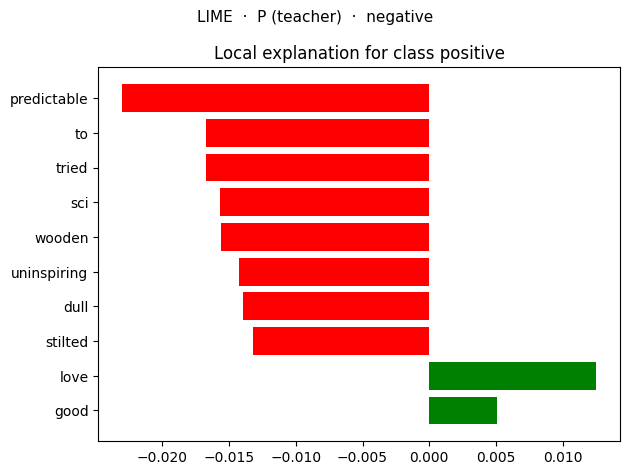

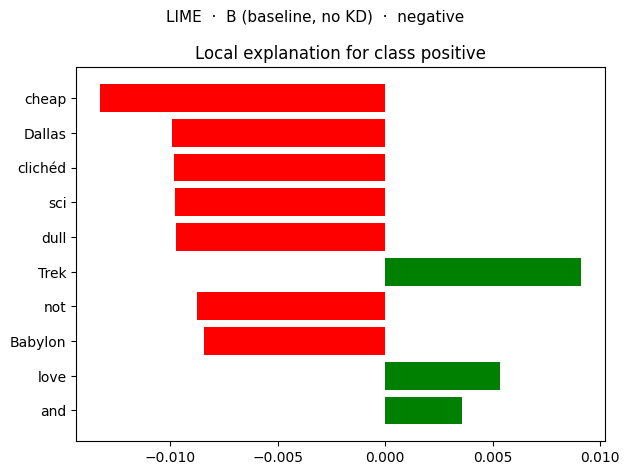

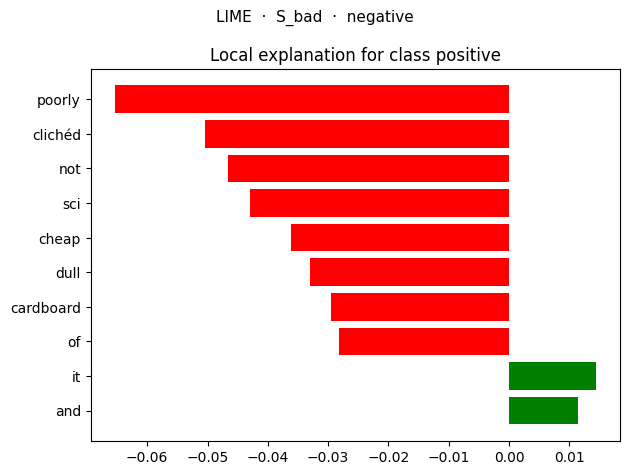

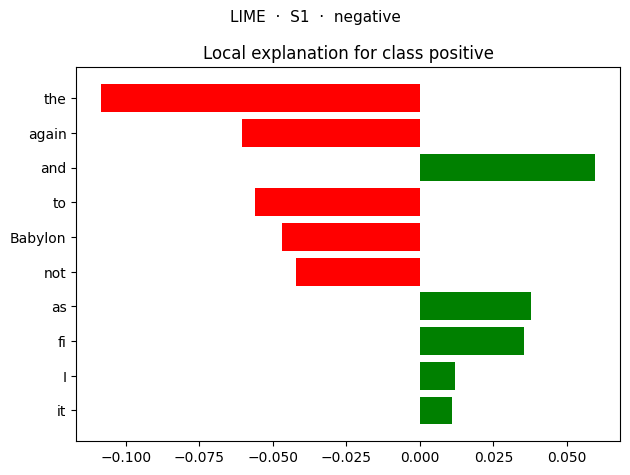

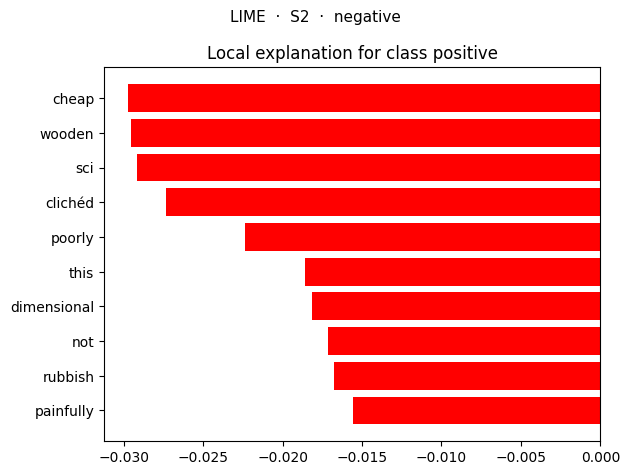

In [13]:
print(f"Qualitative example — NEGATIVE\n")
for name, model in MODELS.items():
    model.to(device)
    exp = LimeTextExplainer(class_names=["negative", "positive"]).explain_instance(
        QUAL_NEG,
        lambda t, m=model: classify_fn(t, model=m),
        num_samples=5000,
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME  ·  {MODEL_LABELS[name]}  ·  negative", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"../images/{name}_lime_neg.png", dpi=150, bbox_inches="tight")
    plt.show()
    model.cpu()
    torch.cuda.empty_cache()

Qualitative example — POSITIVE



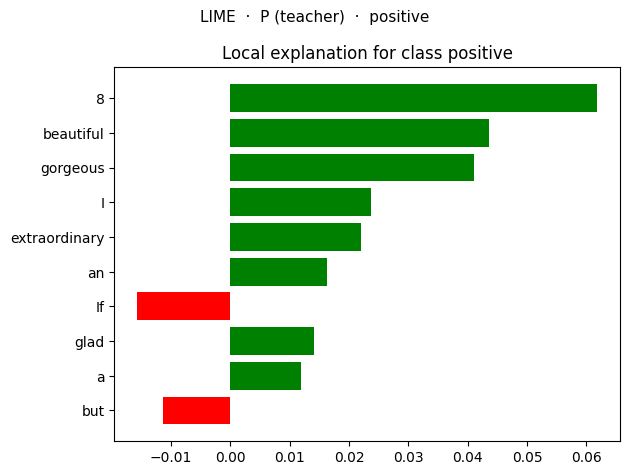

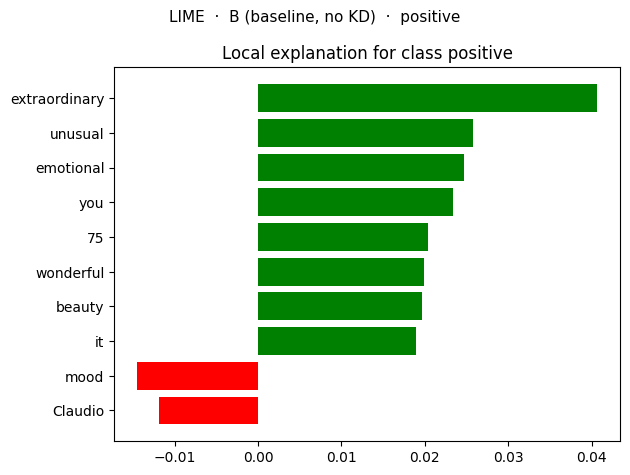

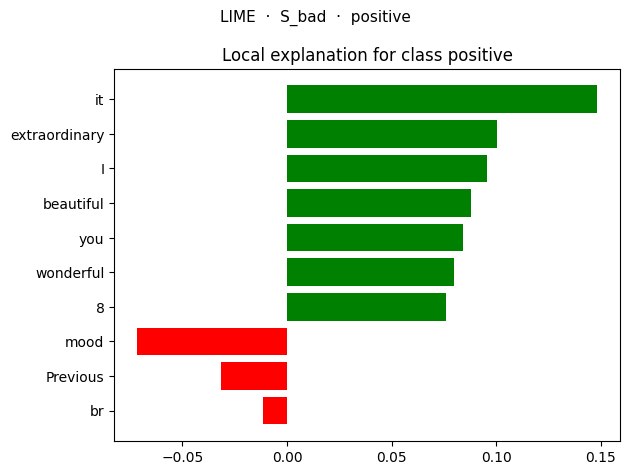

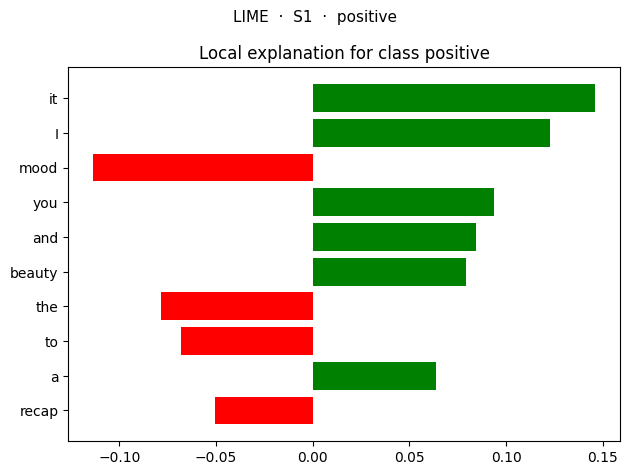

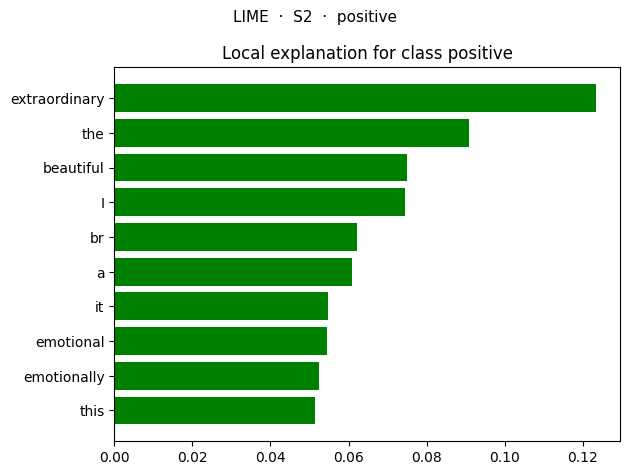

In [14]:
print(f"Qualitative example — POSITIVE\n")
for name, model in MODELS.items():
    model.to(device)
    exp = LimeTextExplainer(class_names=["negative", "positive"]).explain_instance(
        QUAL_POS,
        lambda t, m=model: classify_fn(t, model=m),
        num_samples=5000,
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME  ·  {MODEL_LABELS[name]}  ·  positive", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"../images/{name}_lime_pos.png", dpi=150, bbox_inches="tight")
    plt.show()
    model.cpu()
    torch.cuda.empty_cache()

## SHAP

Qualitative example — NEGATIVE

P (teacher)


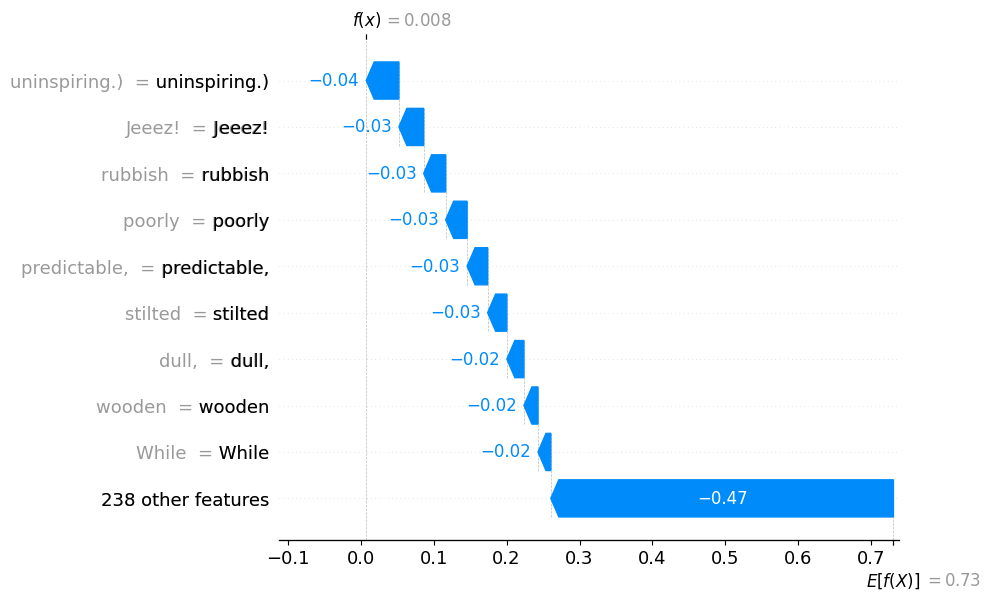

B (baseline, no KD)


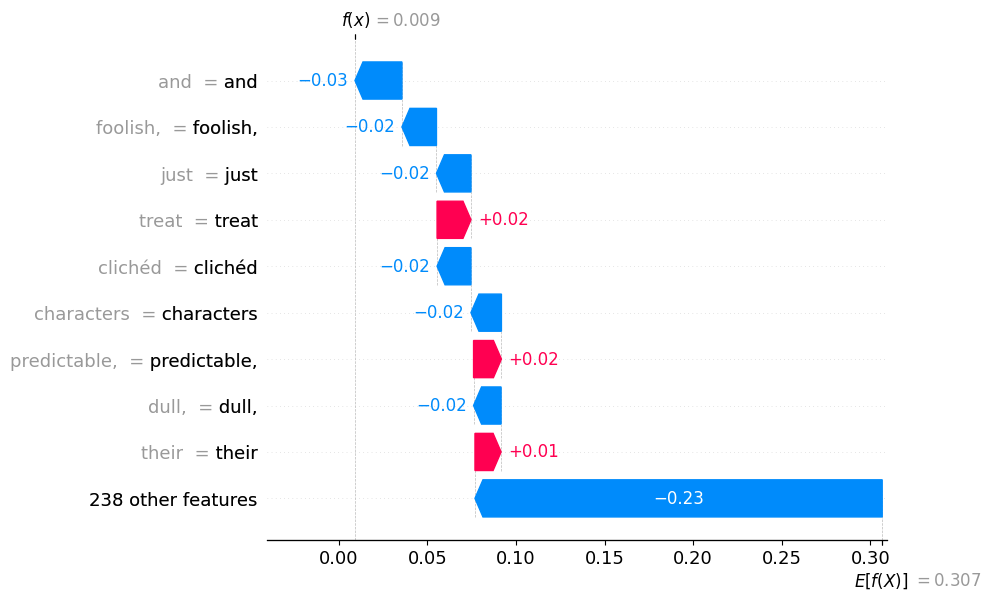

S_bad


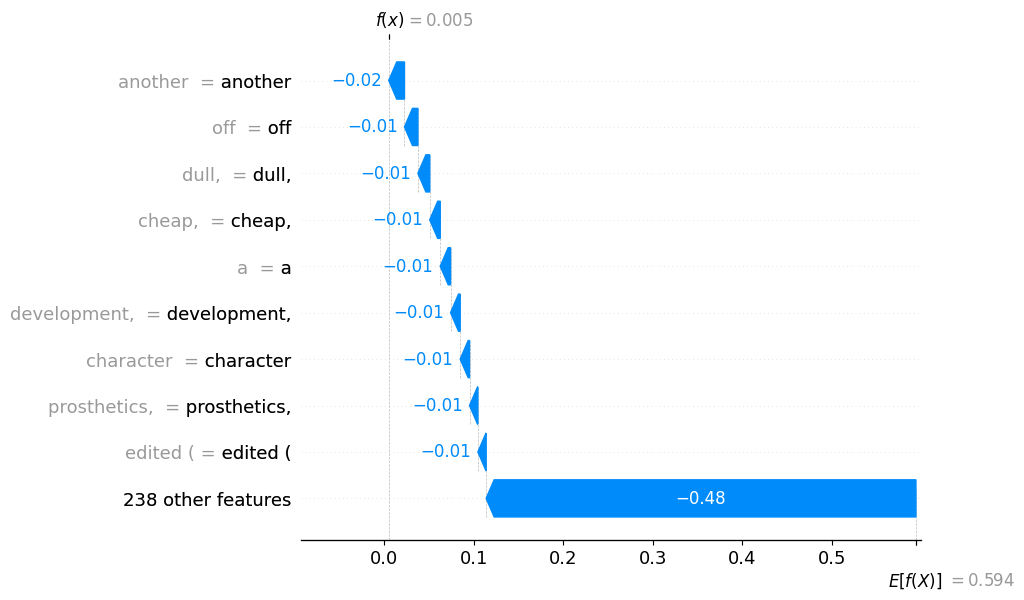

S1


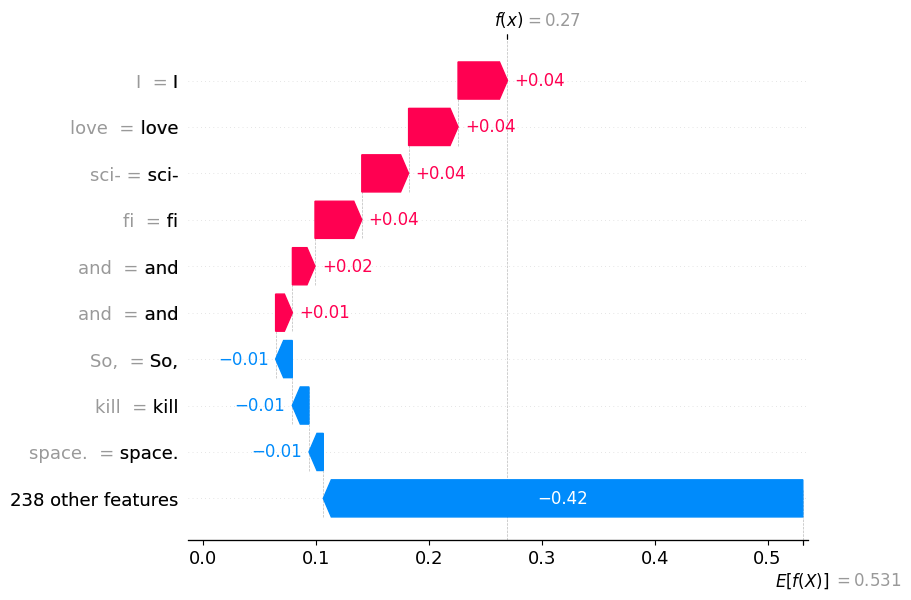

S2


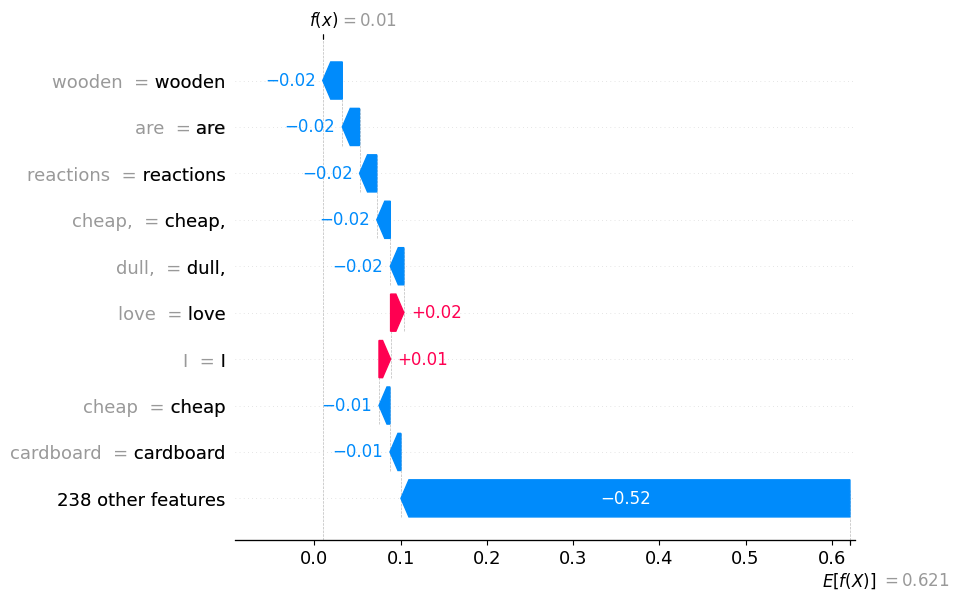

In [15]:
print("Qualitative example — NEGATIVE\n")
for name, model in MODELS.items():
    model.to(device)
    explainer = shap.Explainer(
        lambda t, m=model: classify_fn(t, model=m),
        shap.maskers.Text()
    )
    sv = explainer([QUAL_NEG])
    print(f"{MODEL_LABELS[name]}")
    shap.plots.waterfall(sv[:, :, 1][0], show=False)
    plt.savefig(f"../images/{name}_shap_neg.png", dpi=150, bbox_inches="tight")
    plt.show()
    model.cpu()
    torch.cuda.empty_cache()

Qualitative example — POSITIVE

P (teacher)


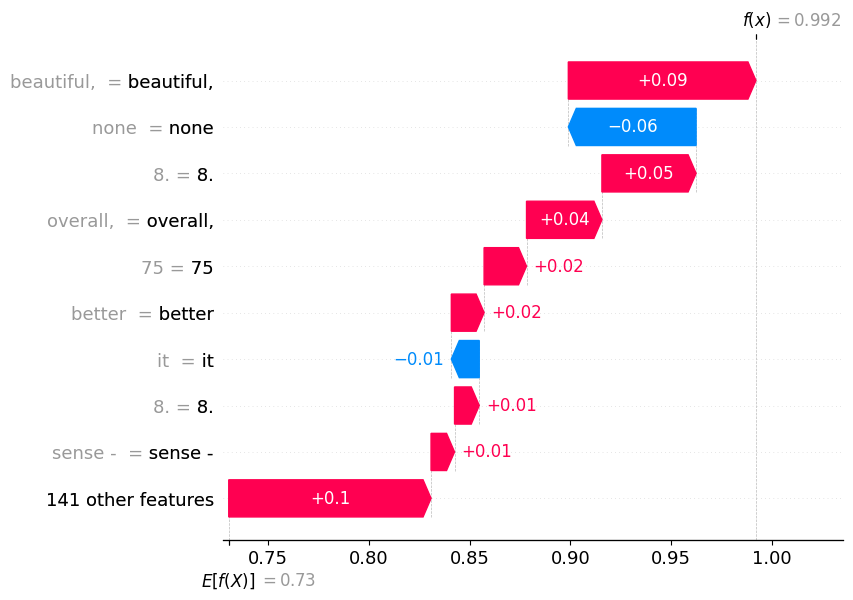

B (baseline, no KD)


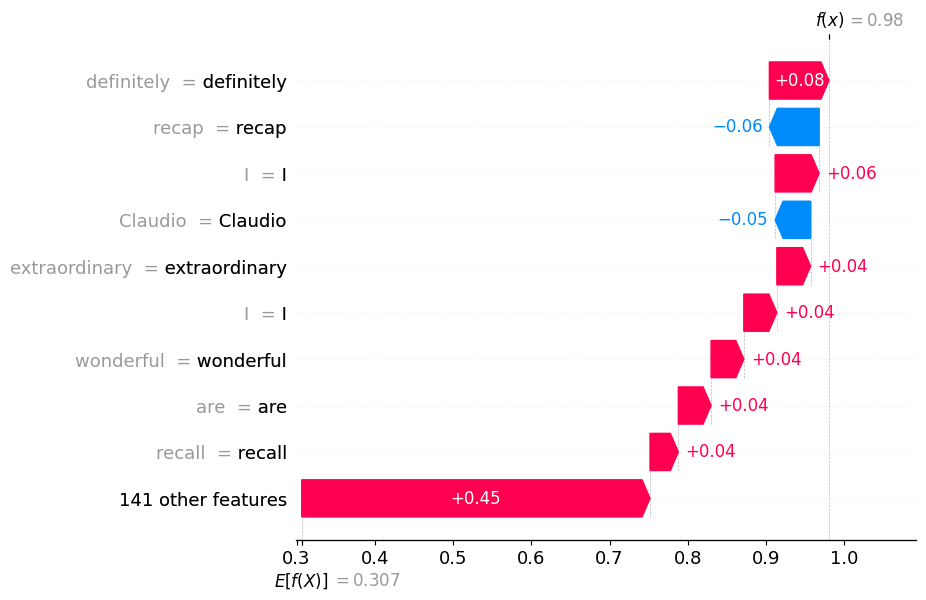

S_bad


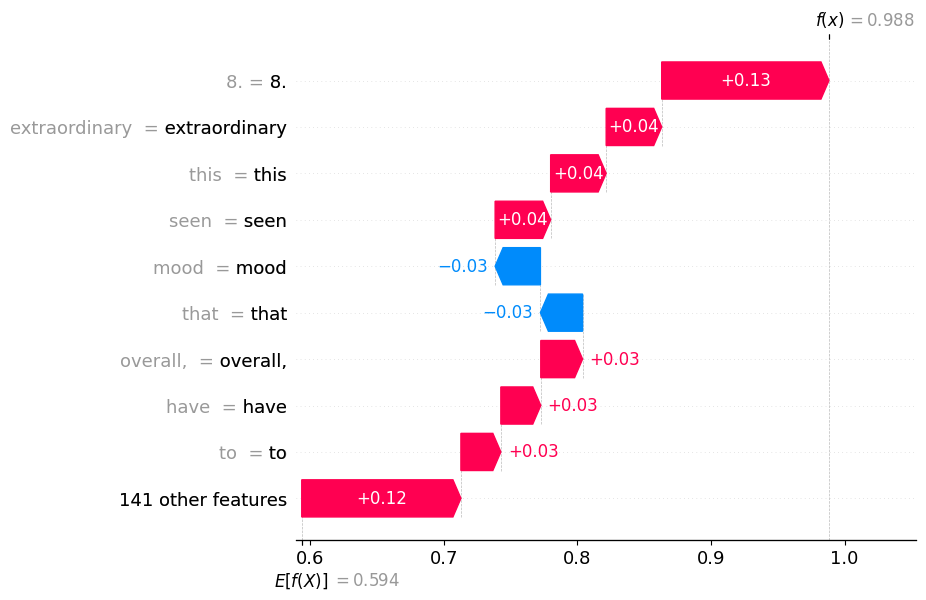

S1


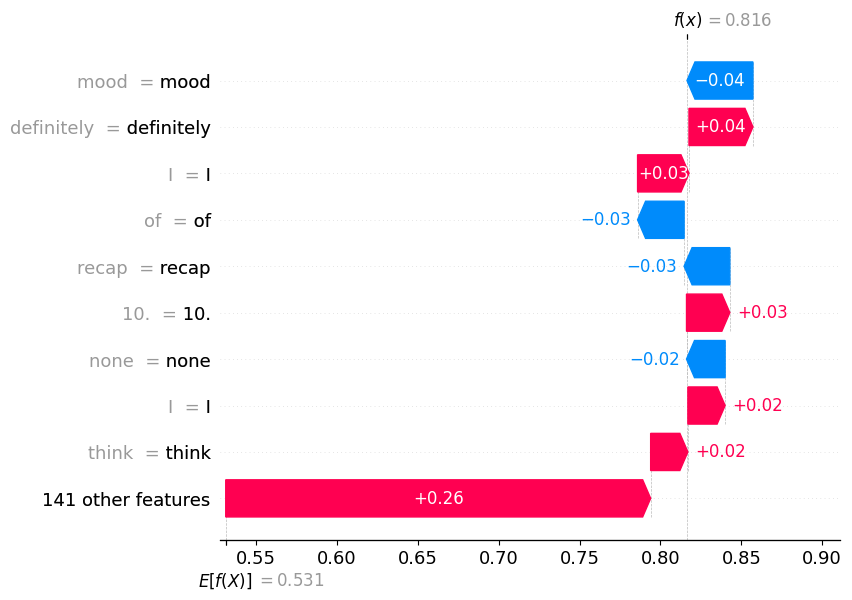

S2


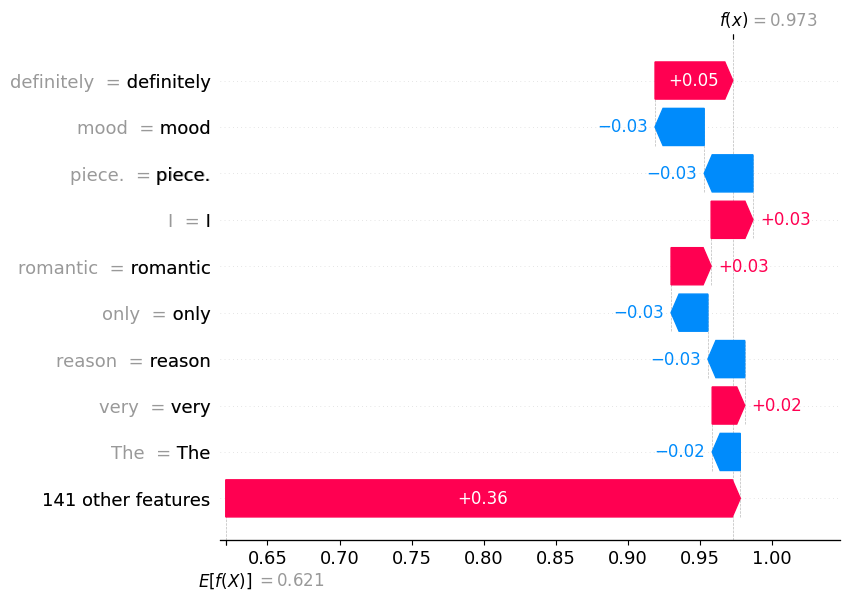

In [16]:
print("Qualitative example — POSITIVE\n")
for name, model in MODELS.items():
    model.to(device)
    explainer = shap.Explainer(
        lambda t, m=model: classify_fn(t, model=m),
        shap.maskers.Text()
    )
    sv = explainer([QUAL_POS])
    print(f"{MODEL_LABELS[name]}")
    shap.plots.waterfall(sv[:, :, 1][0], show=False)
    plt.savefig(f"../images/{name}_shap_pos.png", dpi=150, bbox_inches="tight")
    plt.show()
    model.cpu()
    torch.cuda.empty_cache()

## Integrated Gradients

Qualitative example — NEGATIVE  |  target = positive_id (6374)



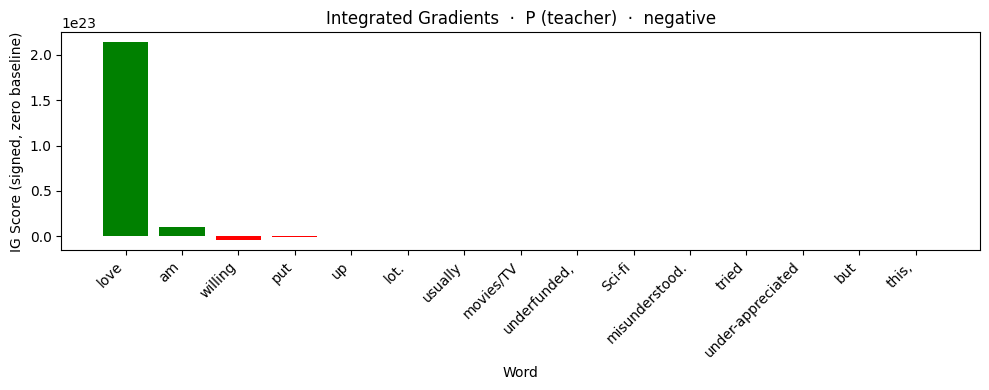

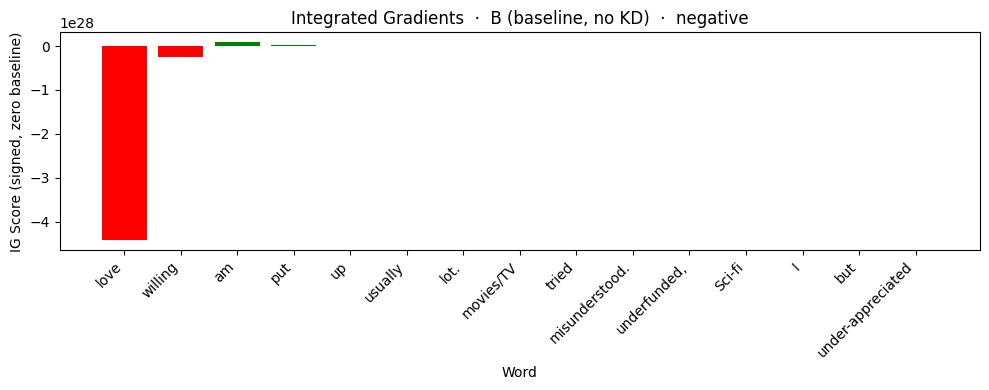

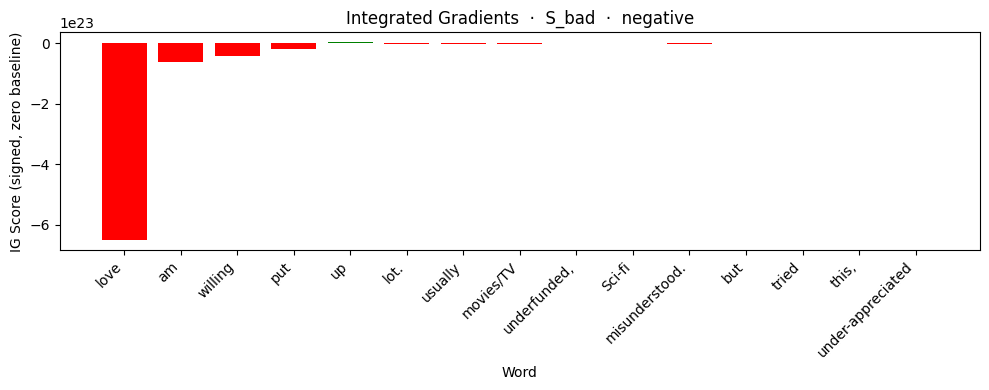

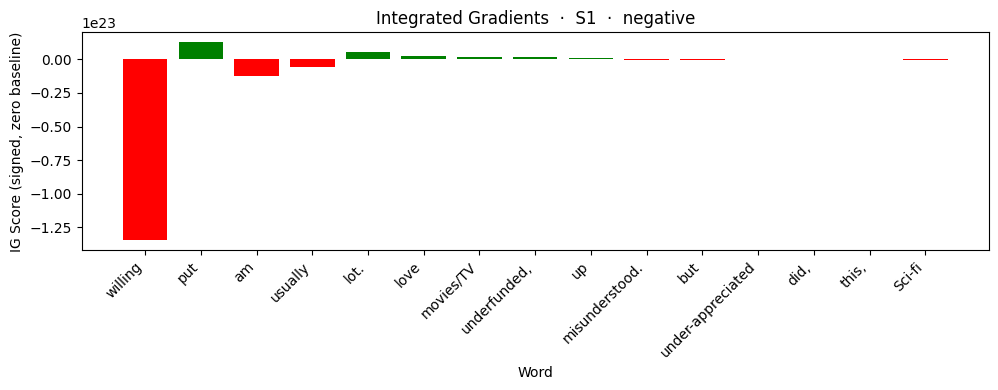

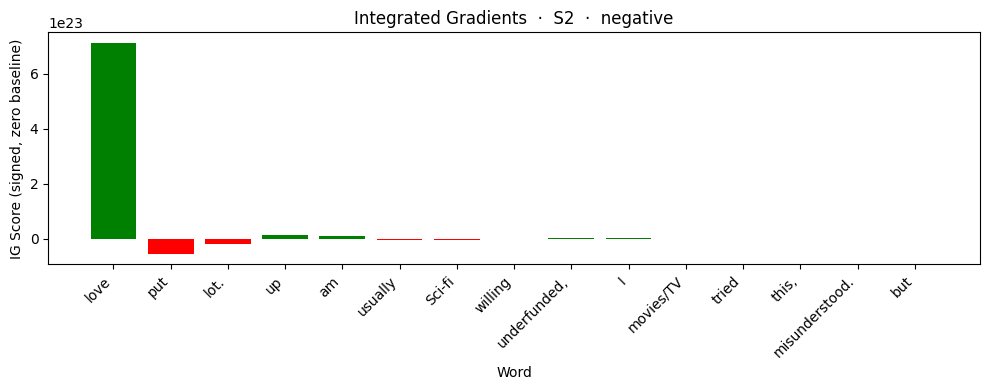

In [17]:
TOP_N = 15
print(f"Qualitative example — NEGATIVE  |  target = positive_id ({positive_id})\n")

for name, model in MODELS.items():
    model.to(device)
    scores = get_ig_scores(model, QUAL_NEG, positive_id)
    model.cpu()
    torch.cuda.empty_cache()

    top_words = sorted(scores, key=lambda w: abs(scores[w]), reverse=True)[:TOP_N]
    top_vals  = [scores[w] for w in top_words]

    plt.figure(figsize=(10, 4))
    plt.bar(range(TOP_N), top_vals,
            color=["green" if v > 0 else "red" for v in top_vals])
    plt.xticks(range(TOP_N), top_words, rotation=45, ha="right")
    plt.xlabel("Word")
    plt.ylabel("IG Score (signed, zero baseline)")
    plt.title(f"Integrated Gradients  ·  {MODEL_LABELS[name]}  ·  negative")
    plt.tight_layout()
    plt.savefig(f"../images/{name}_int_grad_neg.png", dpi=150, bbox_inches="tight")
    plt.show()

Qualitative example — POSITIVE  |  target = positive_id (6374)



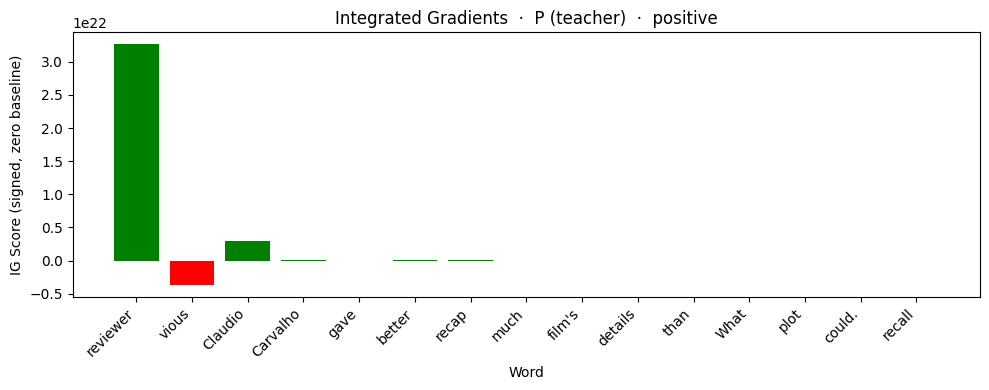

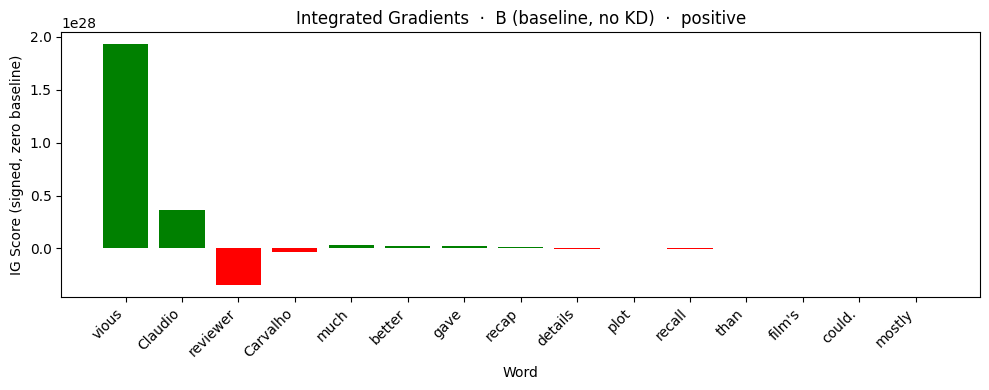

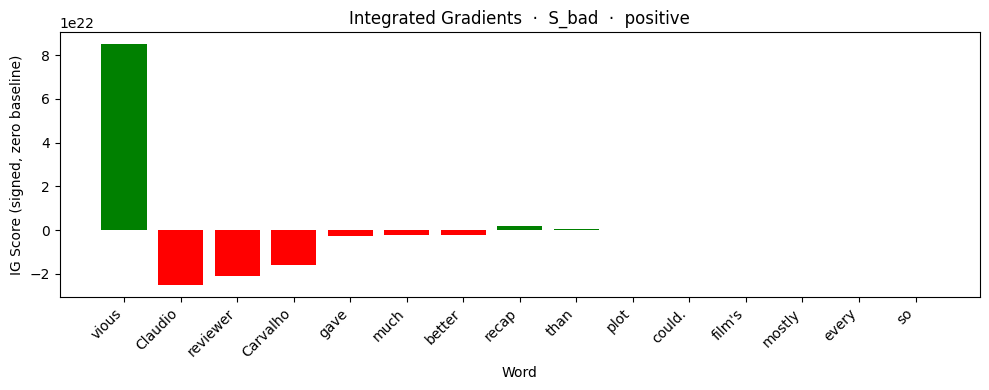

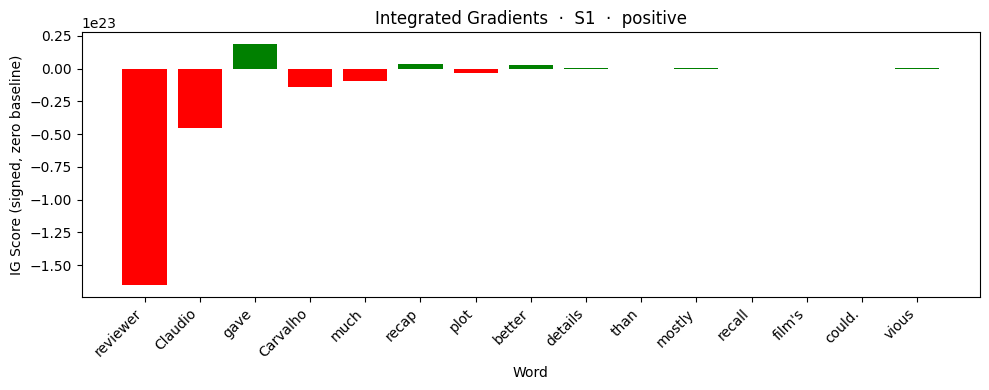

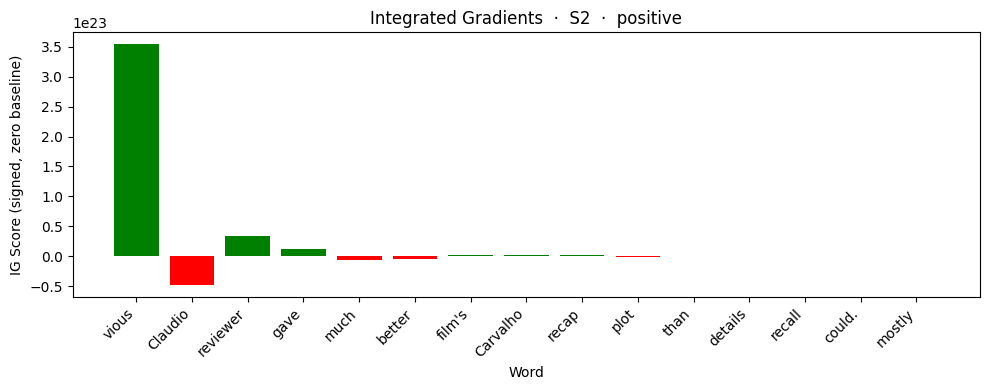

In [18]:
print(f"Qualitative example — POSITIVE  |  target = positive_id ({positive_id})\n")

for name, model in MODELS.items():
    model.to(device)
    scores = get_ig_scores(model, QUAL_POS, positive_id)
    model.cpu()
    torch.cuda.empty_cache()

    top_words = sorted(scores, key=lambda w: abs(scores[w]), reverse=True)[:TOP_N]
    top_vals  = [scores[w] for w in top_words]

    plt.figure(figsize=(10, 4))
    plt.bar(range(TOP_N), top_vals,
            color=["green" if v > 0 else "red" for v in top_vals])
    plt.xticks(range(TOP_N), top_words, rotation=45, ha="right")
    plt.xlabel("Word")
    plt.ylabel("IG Score (signed, zero baseline)")
    plt.title(f"Integrated Gradients  ·  {MODEL_LABELS[name]}  ·  positive")
    plt.tight_layout()
    plt.savefig(f"../images/{name}_int_grad_pos.png", dpi=150, bbox_inches="tight")
    plt.show()

# Aggregate Metrics (N = 100 examples)

In [19]:
K = 10   # top-K for Jaccard and sign agreement

def jaccard_k(scores_a, scores_b, k=K):
    common = set(scores_a) & set(scores_b)
    if not common:
        return 0.0
    a = {w: abs(scores_a[w]) for w in common}
    b = {w: abs(scores_b[w]) for w in common}
    top_a = set(sorted(a, key=a.get, reverse=True)[:k])
    top_b = set(sorted(b, key=b.get, reverse=True)[:k])
    return len(top_a & top_b) / len(top_a | top_b) if (top_a | top_b) else 0.0

def rank_corr(scores_a, scores_b):
    common = list(set(scores_a) & set(scores_b))
    if len(common) < 3:
        return np.nan
    rho, _ = spearmanr([scores_a[w] for w in common], [scores_b[w] for w in common])
    return float(rho)

def pearson_corr(scores_a, scores_b):
    common = list(set(scores_a) & set(scores_b))
    if len(common) < 3:
        return np.nan
    r, _ = pearsonr([scores_a[w] for w in common], [scores_b[w] for w in common])
    return float(r)

def sign_agreement_k(scores_a, scores_b, k=K):
    common = set(scores_a) & set(scores_b)
    if not common:
        return np.nan
    top_a = sorted(common, key=lambda w: abs(scores_a[w]), reverse=True)[:k]
    agr = [np.sign(scores_a[w]) == np.sign(scores_b[w]) for w in top_a if w in scores_b]
    return float(np.mean(agr)) if agr else np.nan

def faithfulness_deletion(model, text, scores, k=K, true_class_idx=1):
    if not scores:
        return np.nan
    top_words   = sorted(scores, key=lambda w: abs(scores[w]), reverse=True)[:k]
    conf_orig   = float(classify_fn([text], model)[0, true_class_idx])
    masked_text = text
    for w in top_words:
        masked_text = masked_text.replace(w, " ")
    conf_masked = float(classify_fn([masked_text], model)[0, true_class_idx])
    return conf_orig - conf_masked

In [20]:
# Compute attributions for all models and methods
# Expected runtime: ~20 min (LIME dominates)

all_attribs = {name: {"lime": [], "shap": [], "ig": []} for name in MODELS}

for name, model in MODELS.items():
    print(f"\n{'='*50}\n{MODEL_LABELS[name]}\n{'='*50}")
    model.to(device)

    for text in tqdm(eval_texts, desc="  LIME"):
        all_attribs[name]["lime"].append(get_lime_scores(model, text, num_samples=2000))

    for text in tqdm(eval_texts, desc="  SHAP"):
        all_attribs[name]["shap"].append(get_shap_scores(model, text))

    for text in tqdm(eval_texts, desc="  IG"):
        all_attribs[name]["ig"].append(get_ig_scores(model, text, positive_id))

    model.cpu()
    torch.cuda.empty_cache()
    print("  Done.")


P (teacher)


  LIME: 100%|██████████| 100/100 [55:12<00:00, 33.12s/it] 
PartitionExplainer explainer: 2it [00:14, 14.76s/it]               
PartitionExplainer explainer: 2it [00:14, 14.60s/it]               
PartitionExplainer explainer: 2it [00:27, 27.04s/it]               
PartitionExplainer explainer: 2it [00:10, 10.64s/it]               
PartitionExplainer explainer: 2it [00:12, 12.46s/it]               
  IG: 100%|██████████| 100/100 [59:39<00:00, 35.79s/it] 


  Done.

B (baseline, no KD)


  IG: 100%|██████████| 100/100 [03:28<00:00,  2.09s/it]


  Done.

S_bad


...

  Done.

S1


  IG: 100%|██████████| 100/100 [03:28<00:00,  2.08s/it]


  Done.

S2


  IG: 100%|██████████| 100/100 [03:30<00:00,  2.10s/it]


  Done.


In [21]:
METHODS       = ["lime", "shap", "ig"]
COMPARE_NAMES = ["baseline", "bad_student", "student", "student_local"]

rows_by_method = {m: [] for m in METHODS}

for method in METHODS:
    t_scores = all_attribs["teacher"][method]

    # ── Teacher faithfulness ─────────────────────────────────────────────
    teacher_model = MODELS["teacher"]
    teacher_model.to(device)
    faiths_t = []
    for i, sc in enumerate(t_scores):
        ci = 1 if eval_labels[i] == "positive" else 0
        faiths_t.append(faithfulness_deletion(teacher_model, eval_texts[i], sc, true_class_idx=ci))
    teacher_model.cpu()
    torch.cuda.empty_cache()

    rows_by_method[method].append({
        "Model":              MODEL_LABELS["teacher"],
        f"Jaccard@{K}":       "—",
        "Spearman ρ":         "—",
        "Pearson corr":       "—",
        f"Sign agr@{K}":      "—",
        f"Faithfulness@{K}":  f"{np.nanmean(faiths_t):.3f}",
    })

    # ── Other models vs teacher ──────────────────────────────────────────
    for model_name in COMPARE_NAMES:
        m_scores = all_attribs[model_name][method]
        model    = MODELS[model_name]
        model.to(device)

        jaccards, spears, pearsons, signs, faiths = [], [], [], [], []
        for i, (ts, ms) in enumerate(zip(t_scores, m_scores)):
            jaccards.append(jaccard_k(ts, ms))
            spears.append(rank_corr(ts, ms))
            pearsons.append(pearson_corr(ts, ms))
            signs.append(sign_agreement_k(ts, ms))
            ci = 1 if eval_labels[i] == "positive" else 0
            faiths.append(faithfulness_deletion(model, eval_texts[i], ms, true_class_idx=ci))

        model.cpu()
        torch.cuda.empty_cache()

        rows_by_method[method].append({
            "Model":              MODEL_LABELS[model_name],
            f"Jaccard@{K}":       f"{np.nanmean(jaccards):.3f}",
            "Spearman ρ":         f"{np.nanmean(spears):.3f}",
            "Pearson corr":       f"{np.nanmean(pearsons):.3f}",
            f"Sign agr@{K}":      f"{np.nanmean(signs):.3f}",
            f"Faithfulness@{K}":  f"{np.nanmean(faiths):.3f}",
        })

for method in METHODS:
    print(f"\n### {method.upper()} — aggregate metrics  (N={len(eval_texts)}, K={K})")
    display(pd.DataFrame(rows_by_method[method]))


### LIME — aggregate metrics  (N=100, K=10)


,Model,Jaccard@10,Spearman ρ,Pearson corr,Sign agr@10,Faithfulness@10
0,P (teacher),—,—,—,—,0.172
1,"B (baseline, no KD)",0.183,0.248,0.359,0.775,0.083
2,S_bad,0.170,0.216,0.329,0.770,0.202
3,S1,0.136,0.189,0.220,0.731,0.177
4,S2,0.212,0.299,0.415,0.796,0.267



### SHAP — aggregate metrics  (N=100, K=10)


,Model,Jaccard@10,Spearman ρ,Pearson corr,Sign agr@10,Faithfulness@10
0,P (teacher),—,—,—,—,0.118
1,"B (baseline, no KD)",0.117,0.239,0.283,0.788,0.025
2,S_bad,0.123,0.238,0.293,0.761,0.093
3,S1,0.096,0.245,0.208,0.723,0.058
4,S2,0.176,0.333,0.387,0.800,0.120



### IG — aggregate metrics  (N=100, K=10)


,Model,Jaccard@10,Spearman ρ,Pearson corr,Sign agr@10,Faithfulness@10
0,P (teacher),—,—,—,—,0.010
1,"B (baseline, no KD)",0.793,-0.005,0.086,0.526,0.010
2,S_bad,0.778,0.028,0.120,0.538,0.085
3,S1,0.814,0.010,-0.021,0.513,0.025
4,S2,0.787,0.039,0.077,0.503,0.019


## LIME Stability (N=20, M=5 runs)

In [22]:
def stability_lime(model, texts, k=K, M=5):
    stabs = []
    for text in texts:
        runs = []
        for seed in range(M):
            sc  = get_lime_scores(model, text, num_samples=2000, seed=seed)
            top = set(sorted(sc, key=lambda w: abs(sc[w]), reverse=True)[:k])
            runs.append(top)
        pairs = [(runs[i], runs[j]) for i in range(M) for j in range(i+1, M)]
        jacs  = [len(a & b) / len(a | b) if (a | b) else 0.0 for a, b in pairs]
        stabs.append(float(np.mean(jacs)))
    return float(np.mean(stabs))

STABILITY_TEXTS = eval_texts[:20]
stab_results    = {}

for name, model in MODELS.items():
    print(f"Stability {MODEL_LABELS[name]} ...")
    model.to(device)
    stab_results[name] = stability_lime(model, STABILITY_TEXTS)
    model.cpu()
    torch.cuda.empty_cache()

stab_df = pd.DataFrame([
    {"Model": MODEL_LABELS[n], f"Stability (mean Jaccard@{K})": f"{v:.3f}"}
    for n, v in stab_results.items()
])
print(f"\n### LIME Stability  (N=20 examples, 5 runs each)")
display(stab_df)

Stability P (teacher) ...
Stability B (baseline, no KD) ...
Stability S_bad ...
Stability S1 ...
Stability S2 ...

### LIME Stability  (N=20 examples, 5 runs each)


,Model,Stability (mean Jaccard@10)
0,P (teacher),0.548
1,"B (baseline, no KD)",0.587
2,S_bad,0.684
3,S1,0.611
4,S2,0.710


# KL Comparisons

In [25]:
def compute_avg_kl(teacher, student, dataloader, device, temperature=1.0):
    teacher.eval()
    student.eval()
    total_kl, n = 0.0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            last_idx = attention_mask.sum(dim=1) - 1
            idx      = torch.arange(input_ids.size(0), device=device)
            t_logits = teacher(input_ids=input_ids, attention_mask=attention_mask).logits[idx, last_idx]
            s_logits = student(input_ids=input_ids, attention_mask=attention_mask).logits[idx, last_idx]
            t_probs     = F.softmax(t_logits / temperature, dim=-1)
            s_log_probs = F.log_softmax(s_logits / temperature, dim=-1)
            kl = F.kl_div(s_log_probs, t_probs, reduction="batchmean")
            total_kl += kl.item() * input_ids.size(0)
            n        += input_ids.size(0)
    return total_kl / n

In [26]:
from torch.utils.data import Subset

# ── Balanced subset for KL: 1500 pos + 1500 neg (fixed seed) ────────────
random.seed(42)
kl_pos_indices = random.sample(pos_indices, 1500)
kl_neg_indices = random.sample(neg_indices, 1500)
kl_indices = kl_neg_indices + kl_pos_indices

kl_dataset = Subset(test_dataset, kl_indices)
kl_loader = DataLoader(kl_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"KL subset: {len(kl_indices)} examples "
      f"({len(kl_neg_indices)} neg / {len(kl_pos_indices)} pos)")

KL subset: 3000 examples (1500 neg / 1500 pos)


In [29]:
teacher_model = MODELS["teacher"]
teacher_model.to(device)

kl_rows = []
for name in COMPARE_NAMES:
    print(name)
    model = MODELS[name]
    model.to(device)
    kl_t1 = compute_avg_kl(teacher_model, model, kl_loader, device, temperature=1.0)
    kl_t2 = compute_avg_kl(teacher_model, model, kl_loader, device, temperature=2.0)
    kl_rows.append({"Model": MODEL_LABELS[name], "KL (T=1)": f"{kl_t1:.4f}", "KL (T=2)": f"{kl_t2:.4f}"})
    model.cpu()
    torch.cuda.empty_cache()

teacher_model.cpu()
display(pd.DataFrame(kl_rows))

baseline
bad_student
student
student_local


,Model,KL (T=1),KL (T=2)
0,"B (baseline, no KD)",2.8473,1.6861
1,S_bad,0.1037,0.1317
2,S1,0.1042,0.1274
3,S2,0.1110,0.1926
